In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import torch

import pertpy as pt
import spVIPESmulti

np.random.seed(42)
torch.manual_seed(42)
sc.settings.set_figure_params(dpi=100, frameon=False)
torch.cuda.is_available()

True

In [9]:
adata = pt.data.kang_2018()

print(f"Shape           : {adata.shape}")
print(f"Cell types      : {adata.obs['cell_type'].nunique()}")
print()

Shape           : (24673, 15706)
Cell types      : 8



In [12]:
adata.obs.columns

Index(['nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster',
       'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT',
       'integrated_snn_res.0.4', 'seurat_clusters'],
      dtype='object')

In [11]:
adata.obs["replicate"].value_counts()

replicate
patient_1015    5090
patient_1488    4580
patient_1256    4134
patient_1016    3358
patient_1244    3343
patient_101     2024
patient_1039    1102
patient_107     1042
Name: count, dtype: int64

In [13]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key="label")
adata = adata[:, adata.var["highly_variable"]].copy()

In [14]:
# Split into per-time-point AnnData objects
conditions = sorted(adata.obs["label"].unique())
adatas_dict = {}
for condition in conditions:
    sub = adata[adata.obs["label"] == condition].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[condition] = sub
    print(f"  {condition}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

  ctrl: (12315, 2000)
  stim: (12358, 2000)


In [ ]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="label",
    label_key="cell_type",
    sample_key="replicate"
)

INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'label'                                                         
INFO     spVIPESmulti: Labels: Using 'cell_type' from adata.obs                                                    
INFO     spVIPESmulti: Samples: Using 'replicate' from adata.obs                                                   
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: Will use: Label-based PoE                                                                   


In [17]:
# Model hyperparameters
N_SHARED   = 30
N_PRIVATE  = 15
N_HIDDEN   = 256
DROPOUT    = 0.1
MAX_EPOCHS = 400
BATCH_SIZE = 512
KL_WARMUP  = 50

model = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    use_batch_norm=False,
    use_layer_norm=True,
    disentangle_preset="full"
)
print(model)

INFO     spVIPESmulti: The model has been initialized                                                              


spVIPESmulti Model with the following params: 
n_hidden: 256, n_dimensions_shared: 30, n_dimensions_private: 15, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Not Trained

In [18]:
# Get group indices from uns (canonical approach matching prepare_adatas output)
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
print("Group sizes:", [len(g) for g in group_indices_list])

# Train
model.train(
    group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=True,
    n_epochs_kl_warmup=KL_WARMUP,
    num_workers=6,
    plan_kwargs={
        "lr_scheduler_type": "cosine",
        "lr_patience": 50}
)


Group sizes: [12315, 12358]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 0.773. Signaling Trainer to stop.


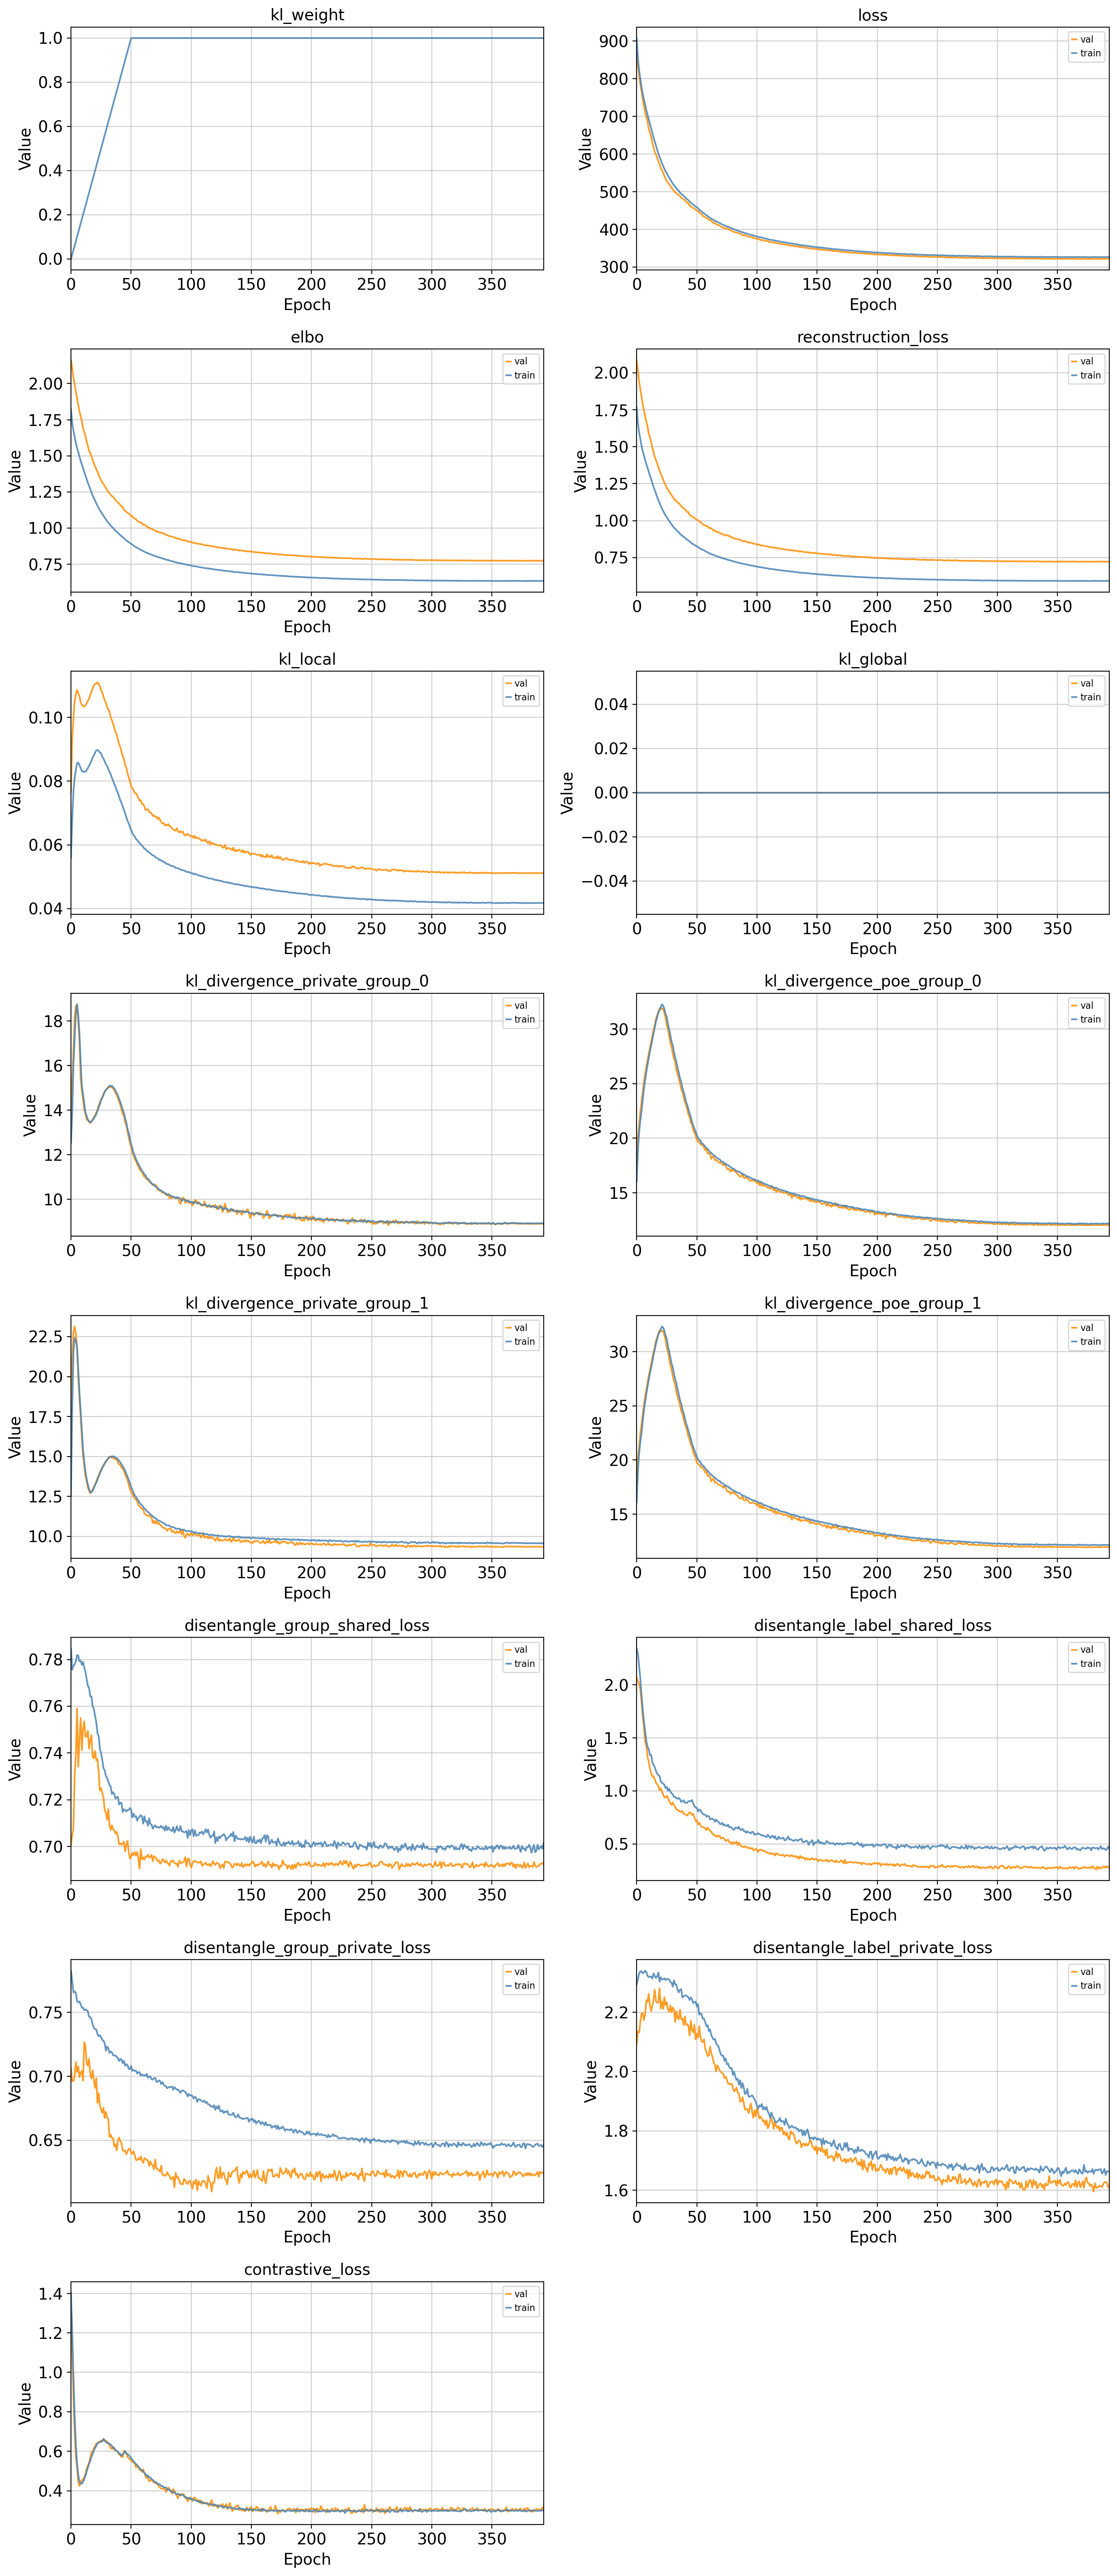

In [19]:
# Multi-panel training history — one panel per tracked metric
fig = spVIPESmulti.pl.training_curves(model)
plt.show()

In [25]:
model.save("results/ifnb_kang", overwrite=True)

model = spVIPESmulti.model.spVIPESmulti.load(
    "results/ifnb_kang", adata=adata_spv
)
print("Model reloaded successfully:")
print(model)

INFO     File results/ifnb_kang/model.pt already downloaded                                                        
INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'label'                                                         
INFO     spVIPESmulti: Labels: Using 'cell_type' from adata.obs                                                    


INFO     spVIPESmulti: Samples: Using 'replicate' from adata.obs                                                   
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: Will use: Label-based PoE                                                                   
INFO     spVIPESmulti: The model has been initialized                                                              
Model reloaded successfully:


spVIPESmulti Model with the following params: 
n_hidden: 256, n_dimensions_shared: 30, n_dimensions_private: 15, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Trained

In [20]:
latents = model.get_latent_representation(group_indices_list, batch_size=BATCH_SIZE)

print("Latent keys:", list(latents.keys()))
for g, tp in enumerate(conditions):
    print(f"  {tp}  shared: {latents['shared_reordered'][g].shape}  "
          f"private: {latents['private_reordered'][g].shape}")

Latent keys: ['shared', 'private', 'shared_reordered', 'private_reordered', 'shared_posterior_loc', 'shared_posterior_scale', 'shared_posterior_loc_reordered', 'shared_posterior_scale_reordered']
  ctrl  shared: (12315, 30)  private: (12315, 15)
  stim  shared: (12358, 30)  private: (12358, 15)


In [26]:
adata_spv

AnnData object with n_obs × n_vars = 24673 × 4000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'groups', 'indices', '_scvi_batch', '_scvi_groups', '_scvi_indices', '_scvi_labels', '_scvi_sample'
    uns: 'groups_var_indices', 'groups_obs_indices', 'groups_obs_names', 'groups_obs', 'groups_lengths', 'groups_var_names', 'groups_mapping', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_spvipesmulti_shared', 'X_spvipesmulti_private_ctrl', 'X_spvipesmulti_private_stim'

In [28]:
# Shared UMAP — runs sc.pp.neighbors + sc.tl.umap on z_shared
spVIPESmulti.utils.compute_shared_umap(
    adata_spv,
    obsm_key="X_spvipesmulti_shared",
    umap_key="X_umap_spvipesmulti_shared",
)

AnnData object with n_obs × n_vars = 24673 × 4000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'groups', 'indices', '_scvi_batch', '_scvi_groups', '_scvi_indices', '_scvi_labels', '_scvi_sample'
    uns: 'groups_var_indices', 'groups_obs_indices', 'groups_obs_names', 'groups_obs', 'groups_lengths', 'groups_var_names', 'groups_mapping', '_scvi_uuid', '_scvi_manager_uuid', '_spvipesmulti_nn_shared', 'umap'
    obsm: 'X_spvipesmulti_shared', 'X_spvipesmulti_private_ctrl', 'X_spvipesmulti_private_stim', 'X_umap', 'X_umap_spvipesmulti_shared'
    obsp: '_spvipesmulti_nn_shared_distances', '_spvipesmulti_nn_shared_connectivities'

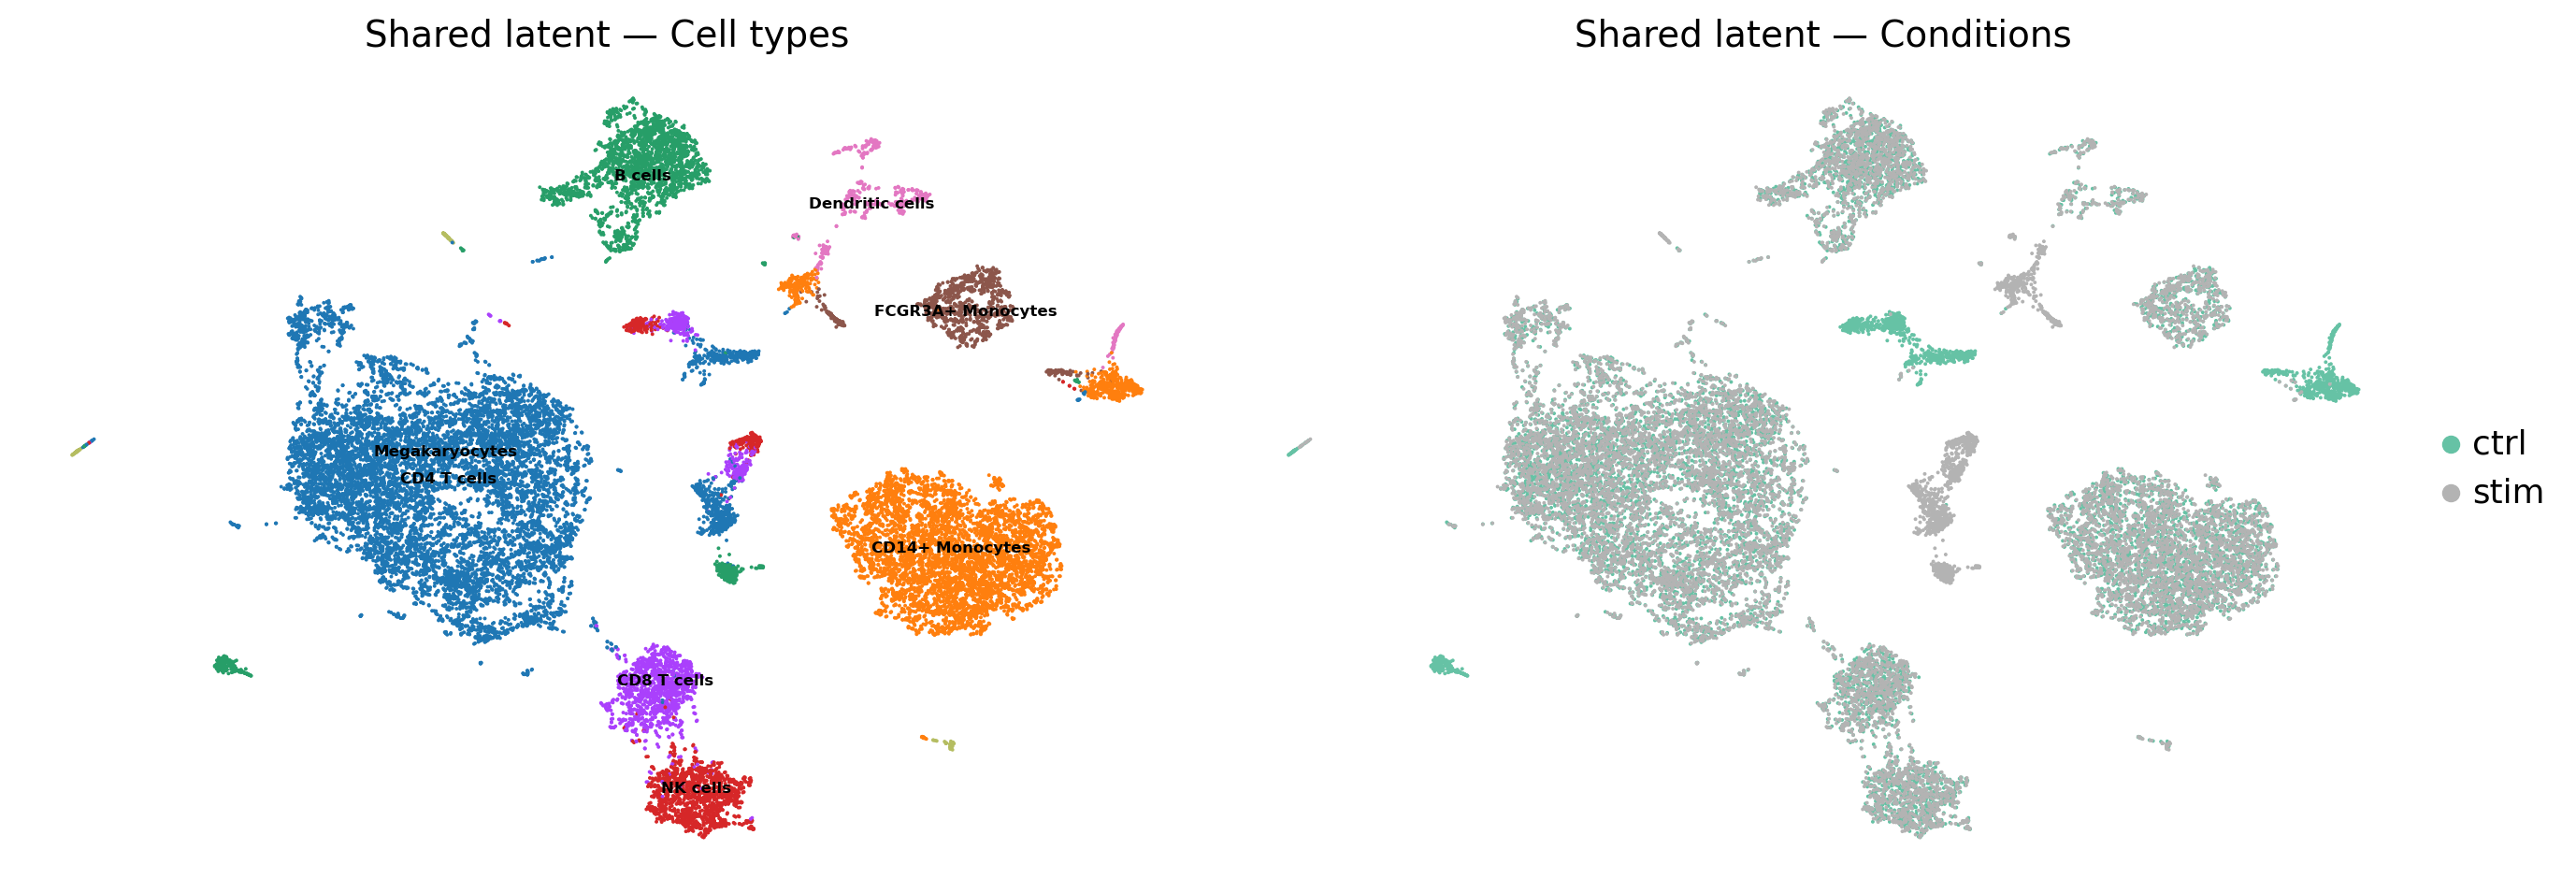

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.embedding(
    adata_spv, basis="X_umap_spvipesmulti_shared", color="cell_type",
    ax=axes[0], show=False, title="Shared latent — Cell types",
    legend_loc="on data", legend_fontsize=6, size=8,
)
sc.pl.embedding(
    adata_spv, basis="X_umap_spvipesmulti_shared", color="label",
    ax=axes[1], show=False, title="Shared latent — Conditions",
    palette="Set2", size=8,
)

#sns.despine()
plt.tight_layout()
plt.show()

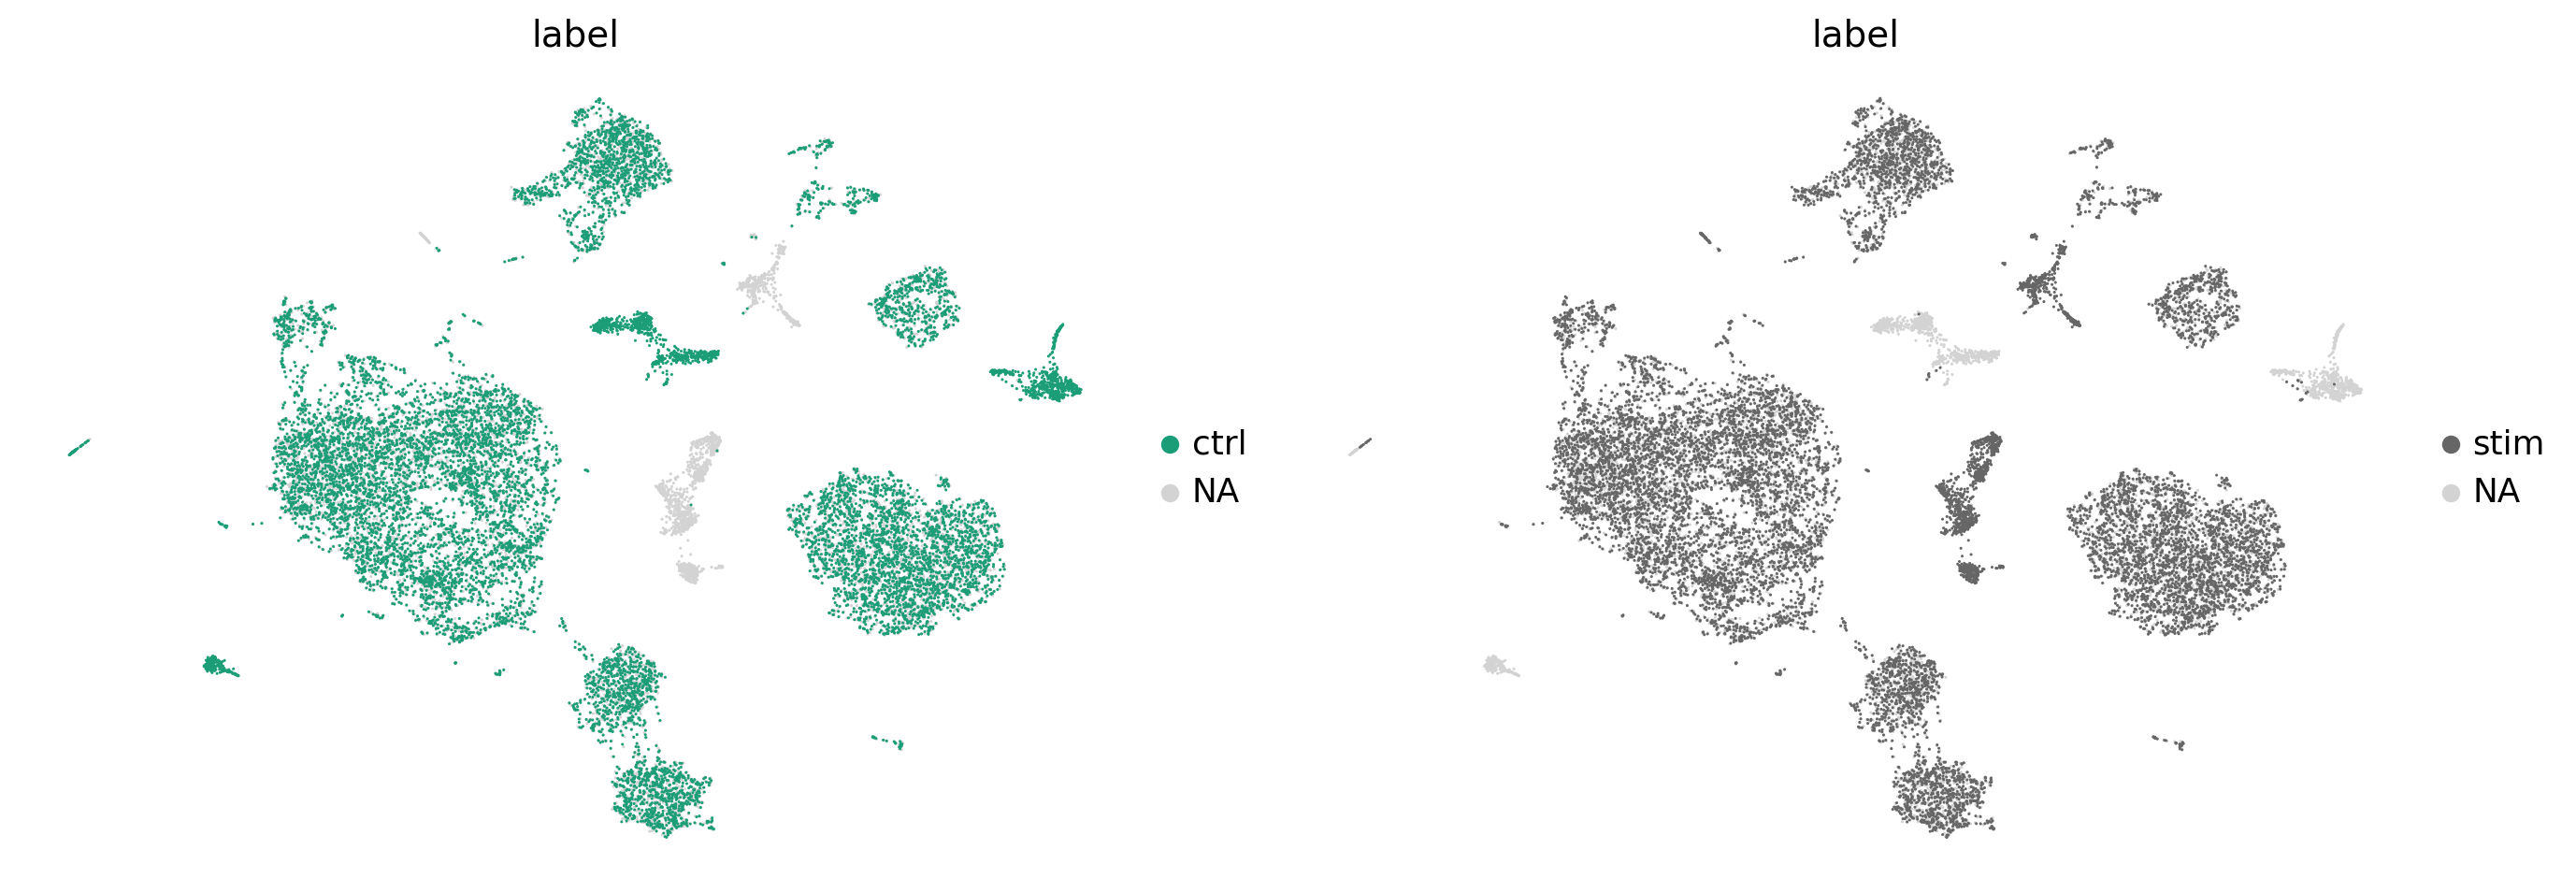

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.embedding(adata_spv, basis="X_umap_spvipesmulti_shared", palette="Dark2",
                color=["label"], groups=["ctrl"], show=False, ax=axes[0])
sc.pl.embedding(adata_spv, basis="X_umap_spvipesmulti_shared", palette="Dark2",
                color=["label"], groups=["stim"], show=False, ax=axes[1])
plt.tight_layout()
plt.show()